<a href="https://colab.research.google.com/github/ofir2207/Cloud-project/blob/main/Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install paho-mqtt



In [4]:
import paho.mqtt.client as mqtt
import json

In [5]:
# Callback function for when a message is received
def on_message(client, userdata, msg):
    try:
        data = json.loads(msg.payload.decode())

        # Extract values with lowercase field names
        temperature = data.get("temperature", "N/A")
        humidity = data.get("humidity", "N/A")
        print(f"Temperature: {temperature}°C, Humidity: {humidity}%")

    except json.JSONDecodeError:
        print("Received invalid JSON data")


In [6]:
# MQTT setup
broker = "io.adafruit.com"
username = "braude6"
aio_key = ""
topic = f"{username}/feeds/json"

client = mqtt.Client()
client.username_pw_set(username,aio_key)
client.on_message = on_message

client.connect(broker, 1883, 60)
client.subscribe(topic)

print(f"Subscribed to MQTT topic: {topic}")
client.loop_forever()


/tmp/ipykernel_5158/2121733669.py:7: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


Subscribed to MQTT topic: braude6/feeds/json


KeyboardInterrupt: 

In [9]:
import requests

USERNAME = "braude6"
AIO_KEY = ""
FEED = "temperature"

url = f"https://io.adafruit.com/api/v2/{USERNAME}/feeds/{FEED}/data"
headers = {"X-AIO-Key": AIO_KEY}

response = requests.get(url, headers=headers)
data = response.json()

for item in data[:5]:  # חמשת הנתונים האחרונים
    print(f"Value: {item['value']}, Time: {item['created_at']}")


Value: 27.00, Time: 2026-05-13T08:31:31Z
Value: 27.00, Time: 2026-05-13T08:31:21Z
Value: 27.00, Time: 2026-05-13T08:31:11Z
Value: 27.00, Time: 2026-05-13T08:31:02Z
Value: 27.00, Time: 2026-05-13T08:30:51Z


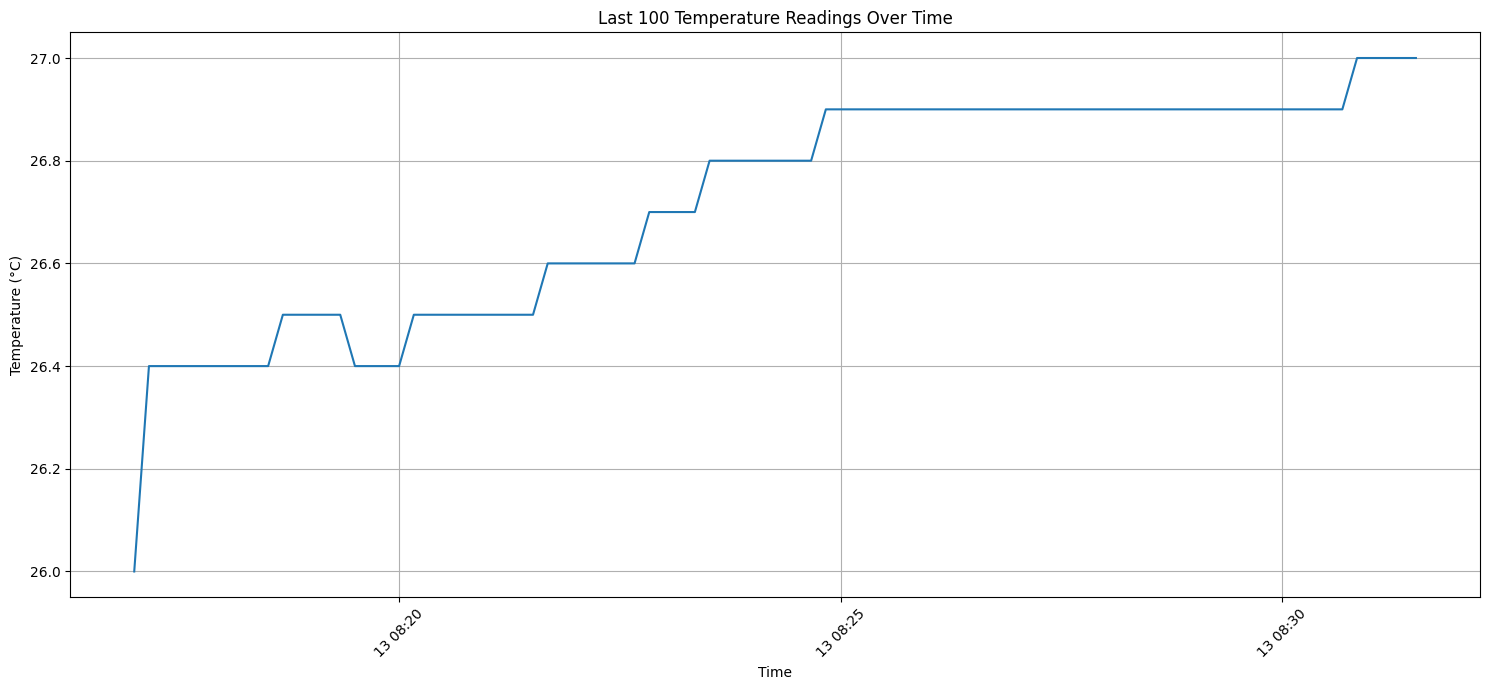

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the last 100 temperature readings and their timestamps
# Assuming 'data' contains the fetched readings from the previous cell
last_100_readings = data[-100:]  # Get the last 100 entries

temperatures = [float(item['value']) for item in last_100_readings]
times = [pd.to_datetime(item['created_at']) for item in last_100_readings]

# Create a Pandas DataFrame
df_temp = pd.DataFrame({
    'Time': times,
    'Temperature': temperatures
})

# Sort by time to ensure correct plotting order
df_temp = df_temp.sort_values(by='Time').reset_index(drop=True)

# Plot the data
plt.figure(figsize=(15, 7))
sns.lineplot(x='Time', y='Temperature', data=df_temp)
plt.title('Last 100 Temperature Readings Over Time')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()